<div class="alert alert-block alert-danger">
	<b>Attention:</b> J'ai fait le choix dans ce notebook, pour simplifier l'intro de ne pas aborder tout de suite la notion de train/test split.
	<p>Normalement, une fois avancé dans votre apprentissage du Machine Learning, certaines parties de ce notebook devraient vous piquer les yeux 😉</p>
</div>

# `scikit-learn`

Documentation : https://scikit-learn.org/stable/user_guide.html

In [1]:
%pip install -q numpy matplotlib ipywidgets


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


(5000, 1)
(5000, 1)


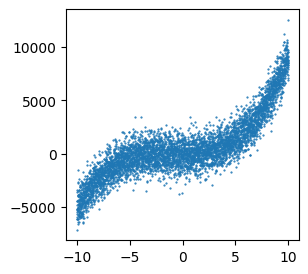

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=2, suppress=True)

NB_POINTS = 5000
COEFFS = [15, 10, 20, 7]
NOISE = 1000

x = np.linspace(-10, 10, NB_POINTS)

y = np.zeros((1, NB_POINTS))
for power, coef in enumerate(COEFFS):
	y += coef * (x**power)

y += np.random.randn(NB_POINTS) * NOISE

x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

print(x.shape)
print(y.shape)

plt.figure(figsize=(3, 3))
plt.scatter(x, y, s=0.3)
plt.show()

## Installation

In [3]:
%pip install -q scikit-learn


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Les modèles

Tous les modèles respectent la même API et implémentent les fonctions :
- `model.fit()` : entrainer le modèle
- `model.score()` : évaluer le modèle
- `model.predict()` : réaliser des prédictions

### LinearRegression

In [4]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[426.77]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[662.75]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[408.33]


In [5]:
print(model.coef_)
print(model.intercept_)

[[426.77]]
[662.75]


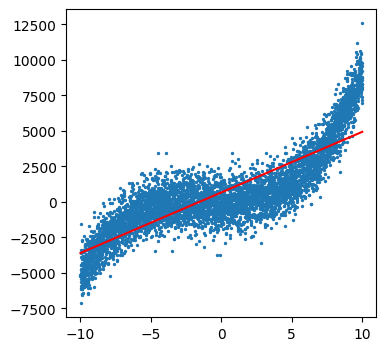

In [6]:
plt.figure(figsize=(4, 4))
plt.scatter(x, y, s=2)
plt.plot(x, model.predict(x), c='r')
plt.show()

### Decision Tree

In [7]:
from sklearn.datasets import load_iris

dataset = load_iris()
x_iris = dataset.data
y_iris = dataset.target
target_names = dataset.target_names
feature_names = dataset.feature_names

print(f"Flower 0: {target_names[y_iris[0]]}")
for i, feature in enumerate(feature_names):
	print(f"- {feature:<20}: {x_iris[0, i]}")

Flower 0: setosa
- sepal length (cm)   : 5.1
- sepal width (cm)    : 3.5
- petal length (cm)   : 1.4
- petal width (cm)    : 0.2


In [8]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=3)
dt_model.fit(x_iris, y_iris)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

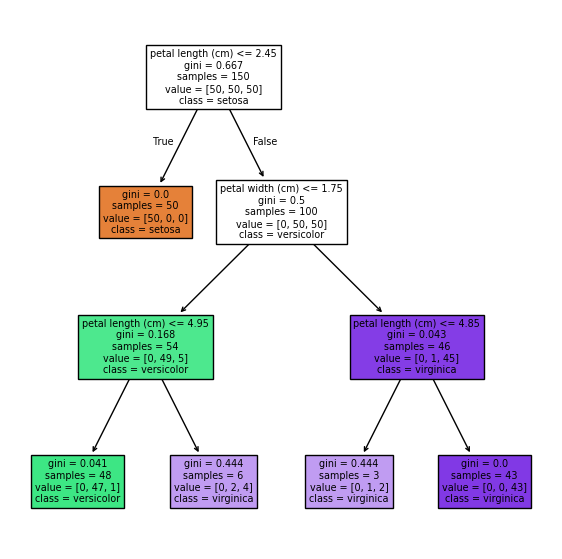

In [9]:
from sklearn.tree import plot_tree

plt.figure(figsize=(7, 7))

plot_tree(dt_model,
		  class_names=dataset.target_names,
		  feature_names=dataset.feature_names,
		  filled=True
		  )
plt.show()

In [10]:
new_flowers = np.array(
	[
		[5.5, 2.5, 3.5, 1.2],
		[5, 4, 1.5, 0.5],
		[5.5, 2.5, 3.5, 1.2],
		[5.0, 3.0, 2.0, 0.75],
		[7, 3, 6, 2],
		[6, 3.2, 4, 1.5],
	]
)
y_preds = dt_model.predict(new_flowers)
print(y_preds)


[1 0 1 0 2 1]


Attention ! La couleur prédite ne fonctionne que si les 3 classes sont présentes dans y_pred


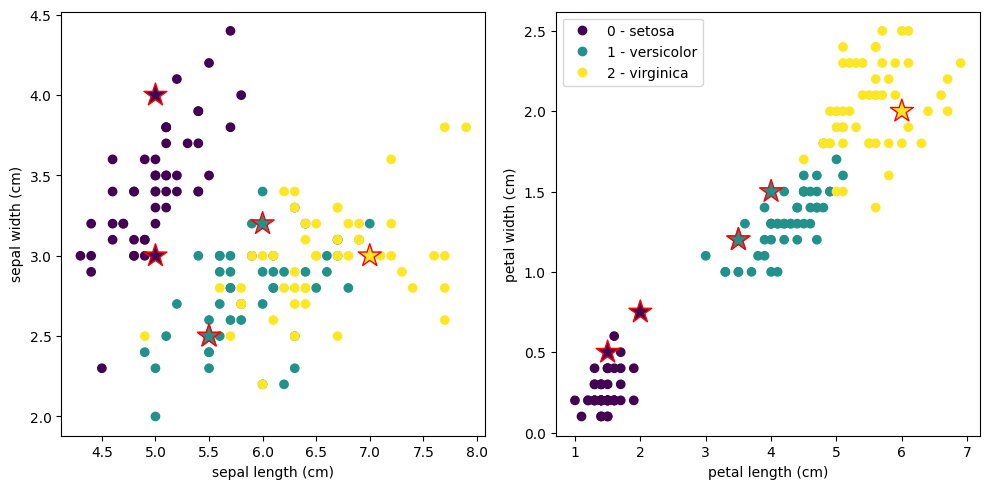

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

sc = ax[0].scatter(x_iris[:, 0], x_iris[:, 1], c=y_iris)
ax[0].set_xlabel(dataset.feature_names[0])
ax[0].set_ylabel(dataset.feature_names[1])
ax[0].scatter(new_flowers[:,0], new_flowers[:,1],c=y_preds, marker='*', s=300, edgecolors='r')

ax[1].scatter(x_iris[:, 2], x_iris[:, 3], c=y_iris)
ax[1].set_xlabel(dataset.feature_names[2])
ax[1].set_ylabel(dataset.feature_names[3])
ax[1].scatter(new_flowers[:,2], new_flowers[:,3], c=y_preds, marker='*', s=300, edgecolors='r')

handles, labels = sc.legend_elements()
labels = ['0 - setosa', '1 - versicolor', '2 - virginica']  # ou les vrais noms : ['setosa', 'versicolor', 'virginica']

plt.legend(handles=handles, labels=labels)
plt.tight_layout()
print("Attention ! La couleur prédite ne fonctionne que si les 3 classes sont présentes dans y_pred")

### Random Forest

In [12]:
from sklearn.ensemble import RandomForestClassifier

NB_TREES = 7 # Use an odd number to avoid 50/50 split

rf_model = RandomForestClassifier(n_estimators=NB_TREES, max_depth=3, bootstrap=True)
rf_model.fit(x_iris, y_iris)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",7
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_tr

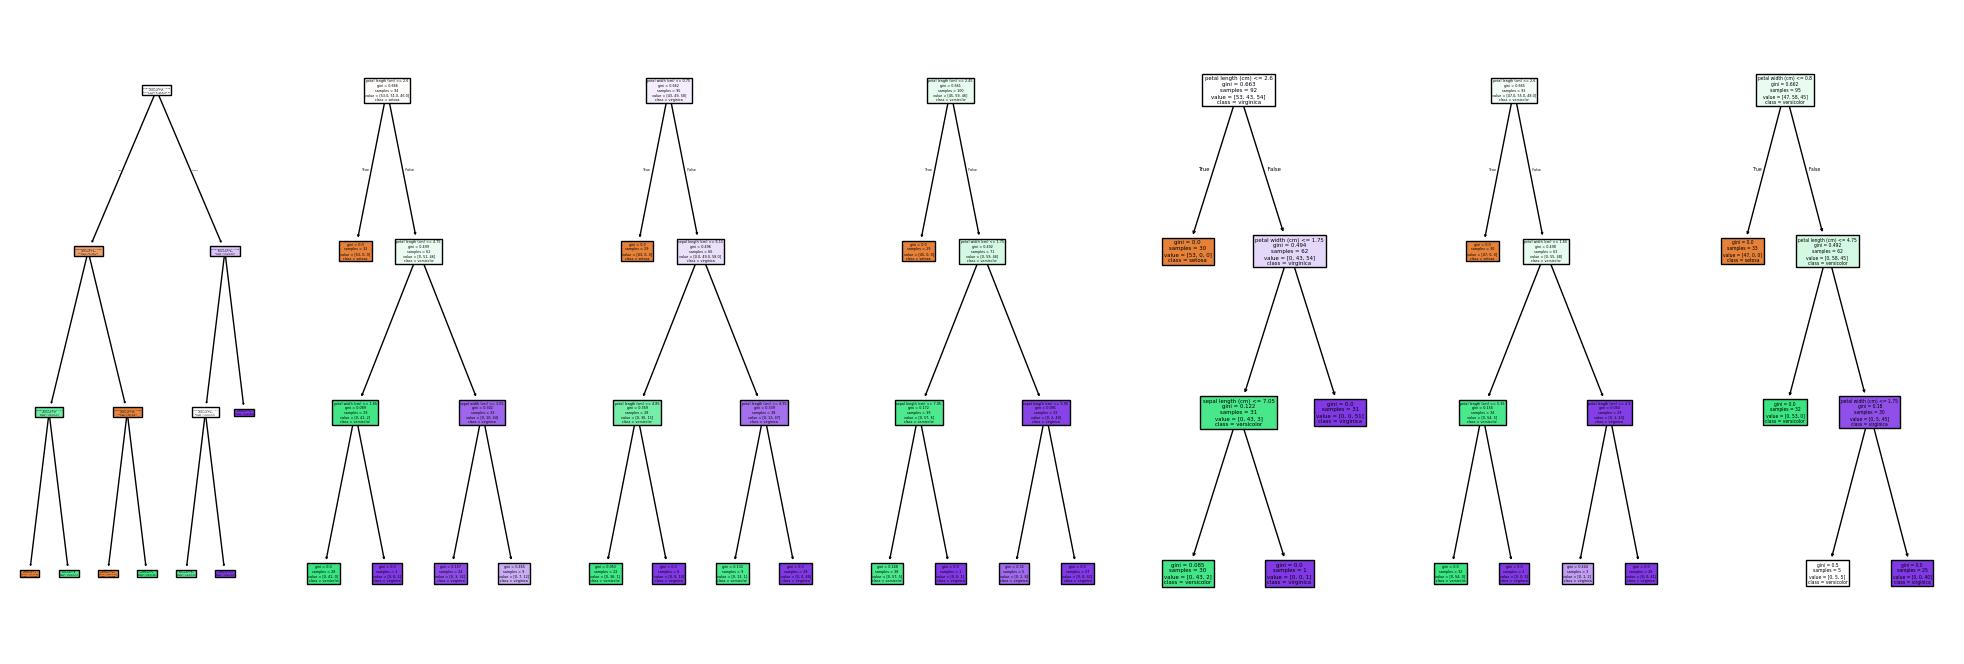

In [13]:
fig, ax = plt.subplots(1, NB_TREES, figsize=(20, 7))

for i in range(NB_TREES):
	plot_tree(rf_model.estimators_[i], ax=ax[i], filled=True, class_names=target_names, feature_names=feature_names)

fig.tight_layout(pad=2)

In [14]:
rf_model.predict(new_flowers)

array([1, 0, 1, 0, 2, 1])

### Multi-layer perceptron

Nous l'aborderons dans le prochain Notebook avec **Tensorflow**, mais pour info, il existe aussi avec sklearn

In [15]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler # cf. plus bas

sc = StandardScaler()
x_iris_std = sc.fit_transform(x_iris)

nn_model = MLPClassifier(hidden_layer_sizes=(5, 5), batch_size=4, early_stopping=True, max_iter=1000, validation_fraction=0.2)
nn_model.fit(x_iris_std, y_iris)

new_flowers_std = sc.transform(new_flowers)

print(nn_model.predict(new_flowers_std))


[1 0 1 0 2 1]


## Preprocessing
### `PolynomialFeatures`

(5000, 1)
(5000, 6)


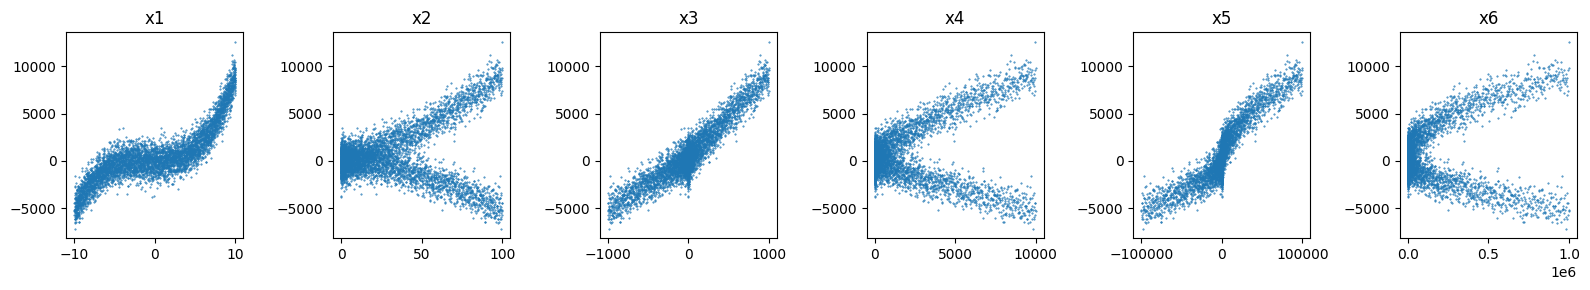

In [16]:
from sklearn.preprocessing import PolynomialFeatures

NB_FEATURES = 6

poly = PolynomialFeatures(NB_FEATURES, include_bias=False)

x_poly = poly.fit_transform(x)
print(x.shape)
print(x_poly.shape)

fig, ax = plt.subplots(1, NB_FEATURES, figsize=(16,3))
for i in range(NB_FEATURES):
	ax[i].scatter(x_poly[:,i], y, s=0.2)
	ax[i].set_title(f"x{i+1}")

plt.tight_layout()

### `StandardScaler`

[-5.14]
[29.04]


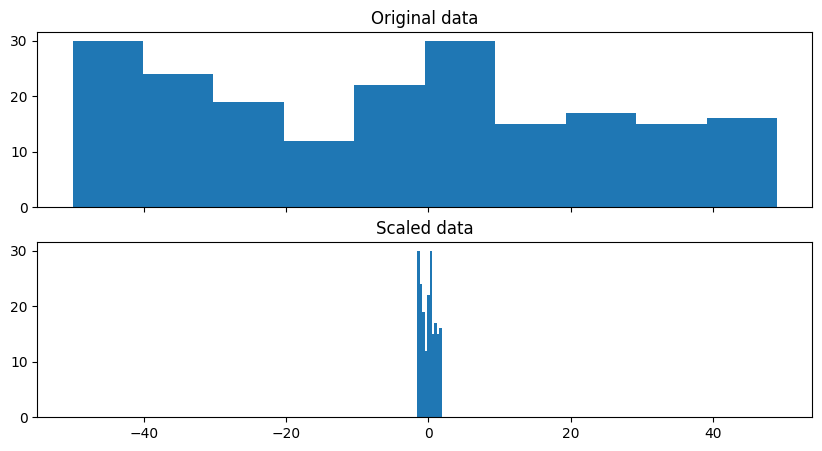

In [17]:
from sklearn.preprocessing import StandardScaler

arr = np.random.randint(-50, 50, 200)
scaler = StandardScaler()

scaled = scaler.fit_transform(arr.reshape(-1, 1))

fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
ax[0].hist(arr)
ax[0].set_title("Original data")
ax[1].hist(scaled)
ax[1].set_title("Scaled data")

print(scaler.mean_)
print(scaler.scale_)

### `MinMaxScaler`

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
Name,Type,Value
"data_max_ data_max_: ndarray of shape (n_features,)Per feature maximum seen in the data.. versionadded:: 0.17 *data_max_*","ndarray[float64](1,)",[48.]
"data_min_ data_min_: ndarray of shape (n_features,)Per feature minimum seen in the data.. versionadded:: 0.17 *data_min_*","ndarray[float64](1,)",[-50.]
"data_range_ data_range_: ndarray of shape (n_features,)Per feature range ``(data_max_ - data_min_)`` seen in the data.. versionadded:: 0.17 *data_range_*","ndarray[float64](1,)",[98.]
"min_ min_: ndarray of shape (n_features,)Per feature adjustment for minimum. Equivalent to``min - X.min(axis=0) * self.scale_``","ndarray[float64](1,)",[51.02]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
"n_samples_seen_ n_samples_seen_: intThe number of samples processed by the estimator.It will be reset on new calls to fit, but increments across``partial_fit`` calls.",int,200
"scale_ scale_: ndarray of shape (n_features,)Per feature relative scaling of the data. Equivalent to``(max - min) / (X.max(axis=0) - X.min(axis=0))``.. versionadded:: 0.17 *scale_* attribute.","ndarray[float64](1,)",[1.02]


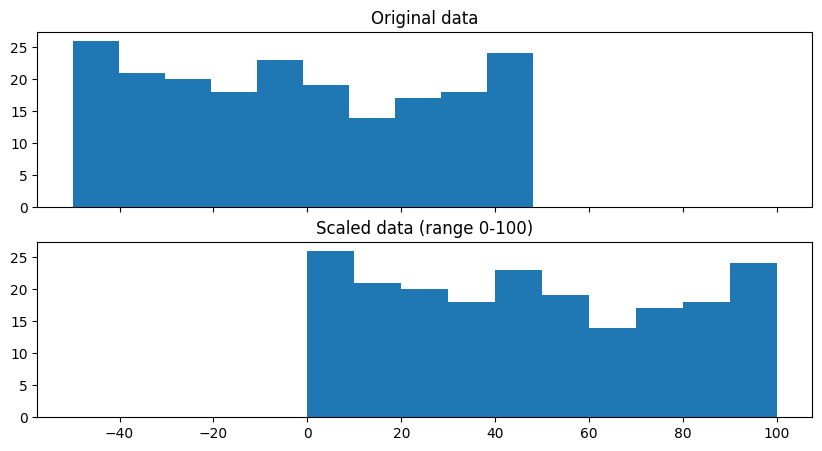

In [18]:
from sklearn.preprocessing import MinMaxScaler

MIN = 0
MAX = 100

arr = np.random.randint(-50, 50, 200)
scaler = MinMaxScaler((MIN, MAX))
scaled = scaler.fit_transform(arr.reshape(-1, 1))

fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
ax[0].hist(arr)
ax[0].set_title("Original data")
ax[1].hist(scaled)
ax[1].set_title(f"Scaled data (range {MIN}-{MAX})")

scaler

## Pipeline

In [19]:
from sklearn.pipeline import Pipeline

model = Pipeline(
	[
		("poly_features", PolynomialFeatures(3, include_bias=True)),
		("lin_reg", LinearRegression(fit_intercept=False)),
	]
)
model.fit(x, y)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('poly_features', ...), ('lin_reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,1
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",3
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
Name,Type,Value


In [20]:
print("Original coefficients (including intercept) : ", COEFFS)
print("Fitted coefficients:                        : ", *model["lin_reg"].coef_)

Original coefficients (including intercept) :  [15, 10, 20, 7]
Fitted coefficients:                        :  [-11.15   2.11  20.21   7.07]


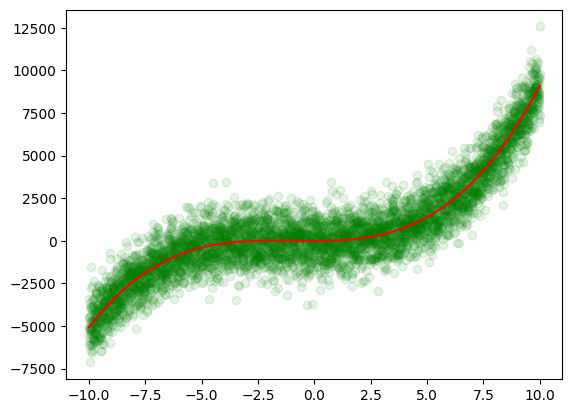

In [21]:
x_to_plot = np.linspace(-10, 10)
y_to_plot = model.predict(x_to_plot.reshape(-1, 1))

plt.scatter(x, y, c='g', alpha=0.1)
plt.plot(x_to_plot, y_to_plot, c='r')

## `train_test_split`

Comme indiqué au début de ce notebook, en machine learning, il est **important** d'évaluer nos modèles sur des nouvelles données.

C'est pourquoi, il est d'usage de réserver une partie du dataset à l'entrainement (le train set) et une autre à l'entrainement (le test set)

scikit-learn dispose d'une fonction simple permettant de séparer une portion d'un dataset

In [22]:
from sklearn.model_selection import train_test_split

print("Shape du dataset Iris: ")
print("input:  ", x_iris.shape)
print("output: ", y_iris.shape)


x_train, x_test, y_train, y_test = train_test_split(x_iris, y_iris, stratify=y_iris, train_size=0.8)

print("Shape du datase Iris après séparation: ")
print("x_train:  ", x_train.shape)
print("y_train: ", y_train.shape)
print("x_test:  ", x_test.shape)
print("y_test: ", y_test.shape)


Shape du dataset Iris: 
input:   (150, 4)
output:  (150,)
Shape du datase Iris après séparation: 
x_train:   (120, 4)
y_train:  (120,)
x_test:   (30, 4)
y_test:  (30,)


Le paramètre `stratify` d'assurer que les classes sont représentées équitablement dans les deux datasets

On peut maintenant utiliser `model.score()` pour évaluer la précision du modèle sur des données inconnues

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf_model_2 = RandomForestClassifier(4)
rf_model_2.fit(x_train, y_train)

print(f"Score on train set: {rf_model_2.score(x_train, y_train):.2%}")
print(f"Score on test set:  {rf_model_2.score(x_test, y_test):.2%}")

Score on train set: 100.00%
Score on test set:  100.00%


# emlearn
## Installation

In [24]:
%pip install -q emlearn


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Convertir un modèle (déjà entrainé)

<div class="alert alert-block alert-warning">
<b>⚠️ Attention</b> Il y a une volontairement une erreur dans le bloc suivant ! (voir plus bas)
</div>


In [25]:
import emlearn

c_model = emlearn.convert(rf_model, method='inline')
c_code = c_model.save("my_tree_model", "model.c")
print(c_code[:200])




    // !!! This file is generated using emlearn !!!

    #include <stdint.h>
    

static inline int32_t my_tree_model_tree_0(const int16_t *features, int32_t features_length) {
          if (featu


In [26]:
print("Predictions from sklearn model:  ", *rf_model.predict(new_flowers))
print("Predictions from C model:        ", *c_model.predict(new_flowers))

Predictions from sklearn model:   1 0 1 0 2 1
Predictions from C model:         2 0 2 1 2 2


<div class="alert alert-block alert-info">
<b> ⬆️  Les prédictions sont différentes entre les deux modèles !!</b>
</div>

Pourquoi ?

Le modèle en C attends des `int16_t` en entrée, nous lui passons des `float` compris entre 0 et 5.

La perte de précision importante explique ces prédictions faussées !

### Solution 1: Modèle en float

In [27]:
import emlearn

c_model_float = emlearn.convert(rf_model, method='inline', dtype='float')
c_code = c_model_float.save("my_tree_model", "model_float.c")
print(c_code[:200])




    // !!! This file is generated using emlearn !!!

    #include <stdint.h>
    

static inline int32_t my_tree_model_tree_0(const float *features, int32_t features_length) {
          if (feature


In [28]:
print("Predictions from sklearn model   : ", *rf_model.predict(new_flowers))
print("Predictions from C (float) model : ", *c_model_float.predict(new_flowers))

Predictions from sklearn model   :  1 0 1 0 2 1


Predictions from C (float) model :  1 0 1 0 2 1


### Solution 2: Scaler les features

In [29]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler((0, 127))
x_iris_scaled = scaler.fit_transform(x_iris)

quantized_model = RandomForestClassifier(NB_TREES, max_depth=7)
quantized_model.fit(x_iris_scaled, y_iris)

c_model_quant = emlearn.convert(quantized_model, method='inline')

new_flowers_scaled = scaler.transform(new_flowers)

print("Predictions from sklearn model:  ", *quantized_model.predict(new_flowers_scaled))
print("Predictions from C model:        ", *c_model_quant.predict(new_flowers_scaled))

Predictions from sklearn model:   1 0 1 0 2 1
Predictions from C model:         1 0 1 0 2 1


La [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html) de MinMaxScaler indique :

>
>The transformation is given by:
>
> `X_std = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))`
>
> `X_scaled = X_std * (max - min) + min`
>
> where min, max = feature_range.

On peut récupérer ces valeurs depuis le MinMaxScaler

In [30]:
FEATURES_MIN = scaler.data_min_
FEATURES_MAX = scaler.data_max_

print("Minimum of each features", FEATURES_MIN)
print("Maximum of each features", FEATURES_MAX)

Minimum of each features [4.3 2.  1.  0.1]
Maximum of each features [7.9 4.4 6.9 2.5]


Qu'il faudra ensuite réimplémenter en C côté MCU.

Implémentation basique :

```c
const float features_min[] = {4.3f, 2.0f, 1.0f, 0.1f};
const float features_max[] = {7.9f, 4.4f, 6.9f, 2.5f};

for (int i = 0; i < 4; i++) {
	scaled_x[i] = (int8_t)(input[i] - features_min[i]) / (features_max[i] - features_min[i]);
}
predict(scaled_x);
```